# ORF (Gamma) vs Field of View, with cumulative integral

Goal:
> Check the ORF plot against the changing FoV to see if [the Gamma(0) != 1 normalization
> issue] comes from there. Take the cumulative integral from 0 to theta of the ORF vs theta
> and plot it on the same changing FoV plot.

This notebook:
1. Plots the Overlap Reduction Function $\Gamma(\theta)$ against $\theta$ for several
   field-of-view (FoV) values, using the same star-field / `ell_min`,`ell_max` convention
   as the rest of the project (`build_star_positions` -> `pairwise_theta` ->
   `compute_ell_limits` -> `gamma_parallel`).
2. Plots the cumulative integral $\int_0^\theta \Gamma(\theta')\,d\theta'$ on the same
   FoV sweep, right below the raw ORF curve.
3. Does this twice: once with the **un-normalized** Gamma (raw multipole sum,
   $\Gamma(0)\approx0.0066$), and once with the **normalized** Gamma
   ($\Gamma(0)\equiv1$, using the `NORMALIZED_GAMMA` toggle in `main.py`), so the two are
   directly comparable.
4. Includes a diagnostic cell checking whether $\Gamma_{\rm raw}(0)$ actually depends on
   FoV (i.e. whether the changing `ell_max` across FoV values is the source of the
   normalization issue, or whether $\Gamma_{\rm raw}(0)$ is a fixed constant regardless of
   FoV).


In [1]:
import sys, os
sys.path.insert(0, ".")   # folder containing main.py / hd_full_matrix_snr.py

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import main as m

matplotlib.use("module://matplotlib_inline.backend_inline")
%matplotlib inline

print("Imports OK.")

Imports OK.


## FoV sweep settings

Same combination style used elsewhere in the project
(`FoV_and_density_diagnostics2.ipynb`): fixed $N$, sweeping FoV from compact to full-sky.
Change `N_STARS_FOR_SWEEP` / `FOV_VALUES_DEG` freely.

In [2]:
N_STARS_FOR_SWEEP = 100
FOV_VALUES_DEG = [10, 40, 90, 160, 360]
SEED = m.RANDOM_SEED

# theta grid to evaluate Gamma(theta) on, degrees and radians
theta_grid_deg = np.linspace(0.01, 179.99, 300)
theta_grid_rad = np.deg2rad(theta_grid_deg)

print(f"N_STARS_FOR_SWEEP = {N_STARS_FOR_SWEEP}")
print(f"FOV_VALUES_DEG    = {FOV_VALUES_DEG}")

N_STARS_FOR_SWEEP = 100
FOV_VALUES_DEG    = [10, 40, 90, 160, 360]


## Helper: ORF + cumulative integral for one FoV

For a given FoV, builds a star field the same way `main.py` does, gets `ell_min`/`ell_max`
from `compute_ell_limits`, evaluates $\Gamma(\theta)$ on the fixed `theta_grid_rad` above (independent of
the star field itself), and returns its cumulative integral
$\int_0^\theta \Gamma(\theta')\,d\theta'$ via trapezoidal integration.

In [3]:
def orf_and_cumulative(fov_deg, normalized, n_stars=N_STARS_FOR_SWEEP, seed=SEED,
                        theta_rad=theta_grid_rad):
    m.NORMALIZED_GAMMA = normalized

    stars = m.build_star_positions(m.STAR_COORDS_DEG, n_stars=n_stars,
                                    field_size_deg=fov_deg, seed=seed)
    theta_matrix = m.pairwise_theta(stars)
    ell_min, ell_max = m.compute_ell_limits(theta_matrix, fov_deg)

    gamma_vals = m.gamma_parallel(theta_rad, ell_min, ell_max)
    cumulative = cumulative_trapezoid(gamma_vals, theta_rad, initial=0.0)

    return gamma_vals, cumulative, ell_min, ell_max

## Diagnostic: does $\Gamma_{\rm raw}(0)$ actually depend on FoV?

Is the $\Gamma(0)\ne1$ issue
coming from the changing `ell_max` across FoV values, or is $\Gamma_{\rm raw}(0)$ a fixed
constant regardless of FoV/`ell_max?

In [4]:
print(f"{'FoV (deg)':>10}  {'ell_min':>8}  {'ell_max':>8}  {'Gamma_raw(0)':>14}")
m.NORMALIZED_GAMMA = False
for fov in FOV_VALUES_DEG:
    stars = m.build_star_positions(m.STAR_COORDS_DEG, n_stars=N_STARS_FOR_SWEEP,
                                    field_size_deg=fov, seed=SEED)
    theta_matrix = m.pairwise_theta(stars)
    ell_min, ell_max = m.compute_ell_limits(theta_matrix, fov)
    gamma0_raw = m.cp_single_star_gamma(ell_min, ell_max)
    print(f"{fov:>10}  {ell_min:>8}  {ell_max:>8}  {gamma0_raw:>14.6f}")

print()
print("If Gamma_raw(0) is essentially constant across all rows above, the Gamma(0)!=1")
print("issue is NOT a FoV/ell_max truncation artifact, it's the F_sq(ell) mode-coupling")
print("weighting itself.")

 FoV (deg)   ell_min   ell_max    Gamma_raw(0)
        10         2     10514        0.006631
        40         2      2617        0.006631
        90         2      1140        0.006631
       160         2       604        0.006631
       360         2       281        0.006631

If Gamma_raw(0) is essentially constant across all rows above, the Gamma(0)!=1
issue is NOT a FoV/ell_max truncation artifact, it's the F_sq(ell) mode-coupling
weighting itself.


## Plot: ORF and cumulative integral vs $\theta$, across FoV

One figure per Gamma convention (un-normalized / normalized), each with two panels:
top = $\Gamma(\theta)$ itself, bottom = its cumulative integral from 0 to $\theta$. Same
FoV sweep, same color per FoV, in both panels.

In [5]:
def make_comparison_plot(normalized, title_suffix, save_name):
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

    for fov in FOV_VALUES_DEG:
        gamma_vals, cumulative, ell_min, ell_max = orf_and_cumulative(fov, normalized)
        label = f"FoV={fov}° (ell_max={ell_max})"
        axes[0].plot(theta_grid_deg, gamma_vals, lw=1.8, label=label)
        axes[1].plot(theta_grid_deg, cumulative, lw=1.8, label=label)

    axes[0].axhline(0, color="gray", lw=0.8)
    axes[0].set_ylabel(r"$\Gamma(\theta)$")
    axes[0].set_title(f"Overlap Reduction Function vs $\\theta$ {title_suffix}")
    axes[0].legend(fontsize=8, loc="upper right")
    axes[0].grid(alpha=0.3)

    axes[1].axhline(0, color="gray", lw=0.8)
    axes[1].set_xlabel(r"$\theta$ (deg)")
    axes[1].set_ylabel(r"$\int_0^\theta \Gamma(\theta')\,d\theta'$")
    axes[1].set_title(f"Cumulative integral of the ORF {title_suffix}")
    axes[1].legend(fontsize=8, loc="upper right")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches="tight")
    plt.show()
    return fig

### Un-normalized Gamma (raw multipole sum, $\Gamma(0)\approx0.0066$)

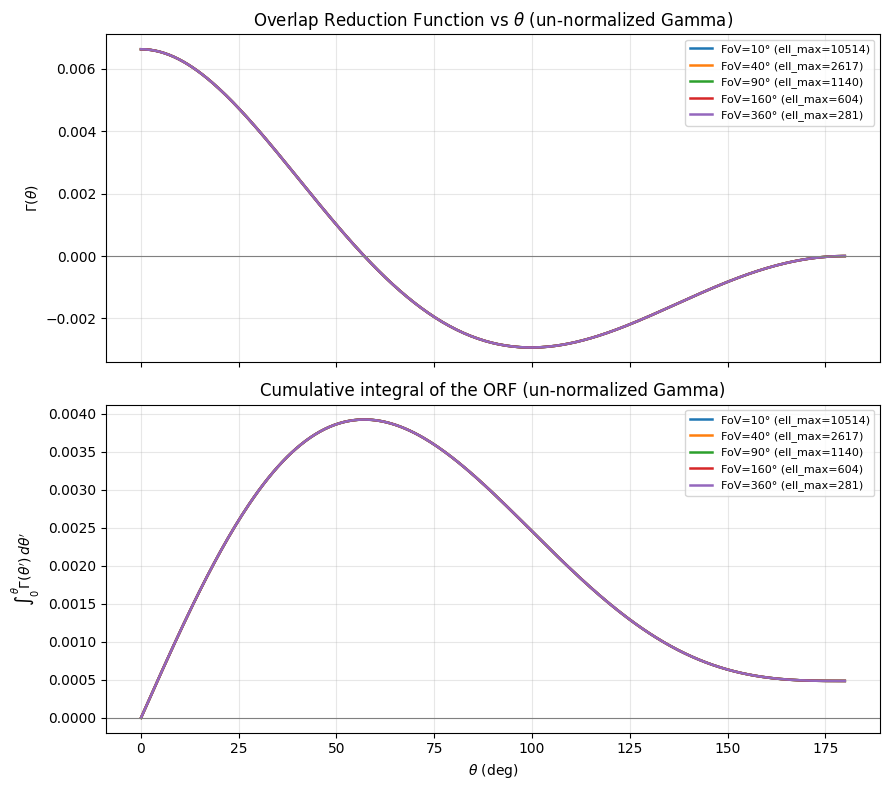

In [6]:
_ = make_comparison_plot(
    normalized=False,
    title_suffix="(un-normalized Gamma)",
    save_name="orf_fov_comparison_unnormalized.png",
)

### Normalized Gamma ($\Gamma(0)\equiv1$)

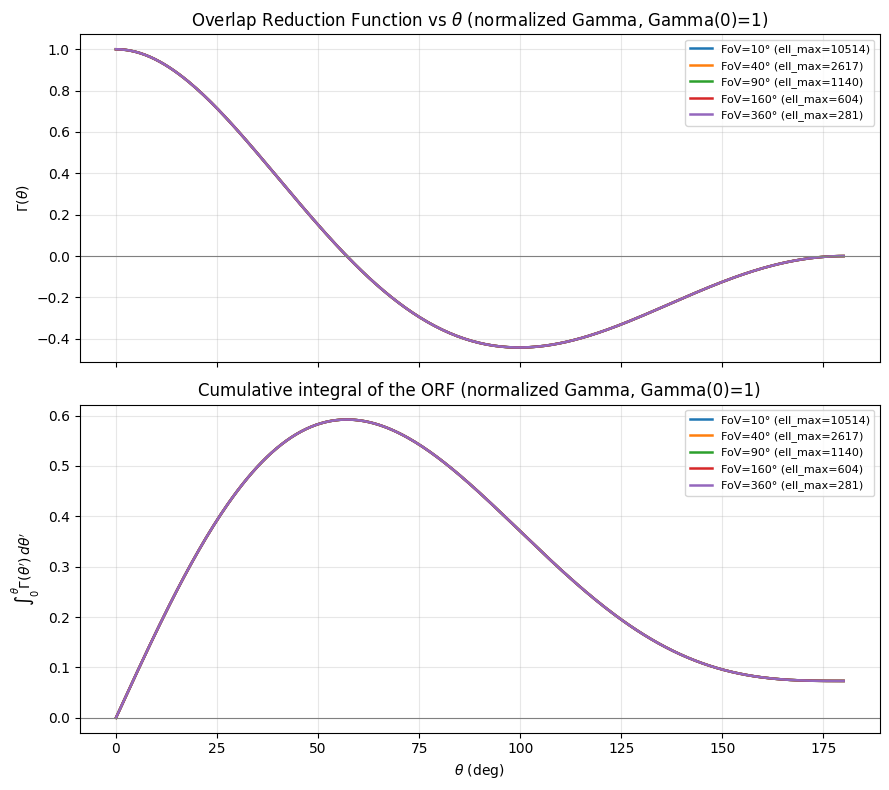

In [7]:
_ = make_comparison_plot(
    normalized=True,
    title_suffix="(normalized Gamma, Gamma(0)=1)",
    save_name="orf_fov_comparison_normalized.png",
)

## Sanity check: the two versions are exact rescalings of each other

Normalizing just divides the whole curve by its own $\theta=0$ value, so the ratio
(normalized / un-normalized) should be a single constant across all $\theta$ and all
FoV equal to $1/\Gamma_{\rm raw}(0)$. This is the same $\sim$151$\times$ factor
discussed for the CP/HD plateau comparison.

In [8]:
fov_check = FOV_VALUES_DEG[0]

# orf_and_cumulative() sets m.NORMALIZED_GAMMA internally, so compute the raw
# gamma0 explicitly (with the toggle forced False) BEFORE anything below can
# leave the toggle in the "True" state -- otherwise this would silently pick
# up the already-normalized value (a mistake worth knowing about: the toggle
# is global module state, not something scoped to a single function call).
m.NORMALIZED_GAMMA = False
stars_check = m.build_star_positions(m.STAR_COORDS_DEG, N_STARS_FOR_SWEEP, fov_check, SEED)
ell_min_check, ell_max_check = m.compute_ell_limits(m.pairwise_theta(stars_check), fov_check)
gamma0_raw_check = m.cp_single_star_gamma(ell_min_check, ell_max_check)

gamma_raw, cum_raw, _, _ = orf_and_cumulative(fov_check, normalized=False)
gamma_norm, cum_norm, _, _ = orf_and_cumulative(fov_check, normalized=True)

with np.errstate(divide="ignore", invalid="ignore"):
    ratio = gamma_norm / gamma_raw

finite_ratio = ratio[np.isfinite(ratio)]
print(f"FoV = {fov_check} deg")
print(f"ratio (normalized/un-normalized), should be constant: "
      f"mean={finite_ratio.mean():.4f}  std={finite_ratio.std():.2e}")
print(f"1 / Gamma_raw(0) = {1.0 / gamma0_raw_check:.4f}   <- should match the mean ratio above")

FoV = 10 deg
ratio (normalized/un-normalized), should be constant: mean=150.7964  std=1.05e-14
1 / Gamma_raw(0) = 150.7964   <- should match the mean ratio above


## Comparison: normalized Gamma vs. chi (Hellings-Downs)

Same comparison as Section 1 of `why_pulsars_dont_spike.ipynb` ("The two kernels, side by
side"), but using **normalized** $\Gamma$ ($\Gamma(0)\equiv1$) instead of the raw,
$F_{\rm PHYS}$-scaled version used there. $\chi(\zeta)$ is Hellings & Downs' standard
closed-form pulsar-timing correlation, already normalized by their own convention
($\chi(0)=0.5$).

In [9]:
def chi_HD(zeta):
    x = (1 - np.cos(zeta)) / 2.0
    with np.errstate(divide="ignore", invalid="ignore"):
        val = 0.5 - 0.25*x + 1.5*x*np.log(x)
    val = np.where(x <= 1e-12, 0.5, val)
    return val

chi_vals = chi_HD(theta_grid_rad)

m.NORMALIZED_GAMMA = True
gamma_norm_vals = m.gamma_parallel(theta_grid_rad, 2, 2000)

print(f"chi(0)             = {chi_vals[0]:.4f}")
print(f"Gamma_normalized(0) = {gamma_norm_vals[0]:.4f}")

chi(0)             = 0.5000
Gamma_normalized(0) = 1.0000


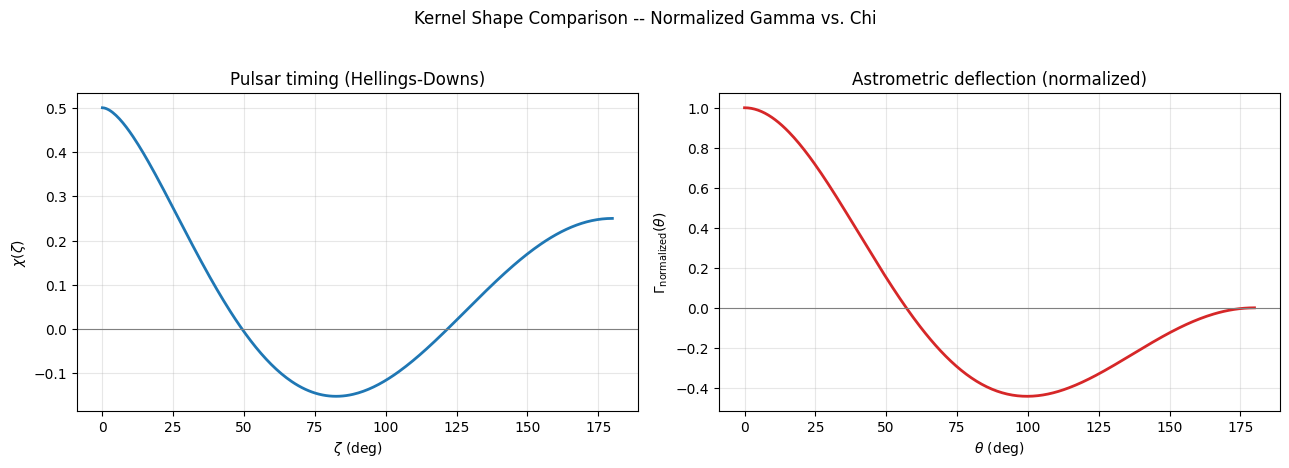

chi(zeta):             2 zero crossing(s)
Gamma_normalized(theta): 1 zero crossing(s)

chi(0)   = 0.5000      chi(179.99 deg)   = 0.2500
Gamma_normalized(0) = 1.0000      Gamma_normalized(179.99 deg) = -0.000000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(theta_grid_deg, chi_vals, color="C0", lw=2)
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set_xlabel(r"$\zeta$ (deg)"); axes[0].set_ylabel(r"$\chi(\zeta)$")
axes[0].set_title("Pulsar timing (Hellings-Downs)")
axes[0].grid(alpha=0.3)

axes[1].plot(theta_grid_deg, gamma_norm_vals, color="C3", lw=2)
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_xlabel(r"$\theta$ (deg)"); axes[1].set_ylabel(r"$\Gamma_{\rm normalized}(\theta)$")
axes[1].set_title("Astrometric deflection (normalized)")
axes[1].grid(alpha=0.3)

plt.suptitle("Kernel Shape Comparison -- Normalized Gamma vs. Chi", y=1.03)
plt.tight_layout()
plt.savefig("kernel_shape_comparison_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

def count_zero_crossings(vals):
    s = np.sign(vals)
    return int(np.sum(np.diff(s) != 0))

print(f"chi(zeta):             {count_zero_crossings(chi_vals)} zero crossing(s)")
print(f"Gamma_normalized(theta): {count_zero_crossings(gamma_norm_vals)} zero crossing(s)")
print(f"\nchi(0)   = {chi_vals[0]:.4f}      chi(179.99 deg)   = {chi_vals[-1]:.4f}")
print(f"Gamma_normalized(0) = {gamma_norm_vals[0]:.4f}      "
      f"Gamma_normalized(179.99 deg) = {gamma_norm_vals[-1]:.6f}")

### Bonus: direct overlay

Raw $\Gamma$ (~0.0066 at $\theta=0$) and $\chi$ (0.5 at $\zeta=0$) were on different scales,
so overlaying them on one axis wasn't very informative before. Now that $\Gamma(0)=1$ puts
both curves on a comparable O(1) scale, a direct overlay is actually meaningful.

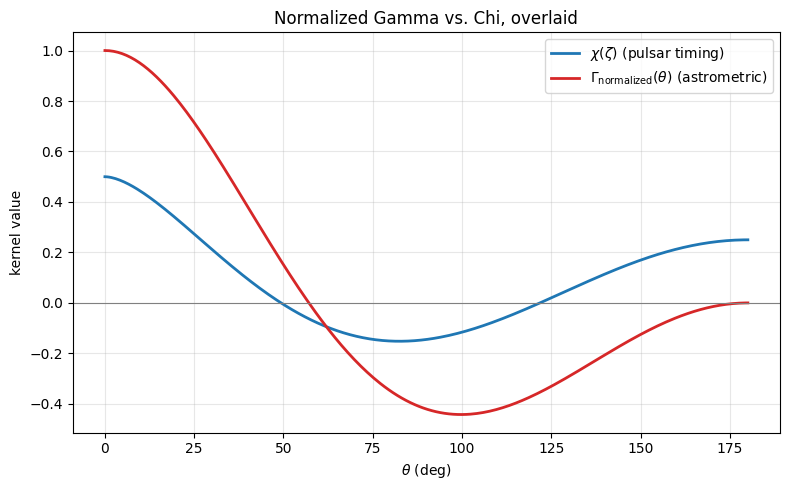

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(theta_grid_deg, chi_vals, color="C0", lw=2, label=r"$\chi(\zeta)$ (pulsar timing)")
ax.plot(theta_grid_deg, gamma_norm_vals, color="C3", lw=2,
        label=r"$\Gamma_{\rm normalized}(\theta)$ (astrometric)")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel(r"$\theta$ (deg)")
ax.set_ylabel("kernel value")
ax.set_title("Normalized Gamma vs. Chi, overlaid")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kernel_overlay_normalized.png", dpi=150, bbox_inches="tight")
plt.show()